In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
data = {
    "Month": ["Jan","Jan","Feb","Feb","Mar","Mar","Apr","Apr","May","May","Jun","Jun"],
    "Product": ["Phones","Accessories"] * 6,
    "Units Sold": [120,200,150,260,180,310,220,380,260,450,300,520],
    "Unit Price": [50,30,50,28,48,27,45,25,43,24,40,22]
}

df = pd.DataFrame(data)
df["Revenue"] = df["Units Sold"] * df["Unit Price"]

df

,Month,Product,Units Sold,Unit Price,Revenue
0,Jan,Phones,120,50,6000
1,Jan,Accessories,200,30,6000
2,Feb,Phones,150,50,7500
3,Feb,Accessories,260,28,7280
4,Mar,Phones,180,48,8640
5,Mar,Accessories,310,27,8370
6,Apr,Phones,220,45,9900
7,Apr,Accessories,380,25,9500
8,May,Phones,260,43,11180
9,May,Accessories,450,24,10800


In [35]:
file_path = "/content/drive/MyDrive/Phones_Accessories_Sales_Data.csv"
df.to_csv(file_path, index=False)

file_path

'/content/drive/MyDrive/Phones_Accessories_Sales_Data.csv'

In [36]:
total_revenue = df["Revenue"].sum()
total_units = df["Units Sold"].sum()
avg_price = df["Unit Price"].mean()
revenue_per_unit = total_revenue / total_units

kpis = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Units Sold", "Average Unit Price", "Revenue per Unit"],
    "Value": [total_revenue, total_units, avg_price, revenue_per_unit]
})

kpis

,Metric,Value
0,Total Revenue,108610.000000
1,Total Units Sold,3350.000000
2,Average Unit Price,36.000000
3,Revenue per Unit,32.420896


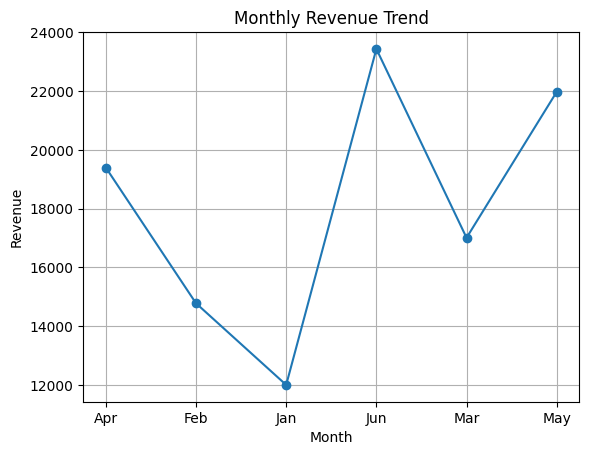

In [37]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure()
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/monthly_revenue_trend.png")
plt.show()

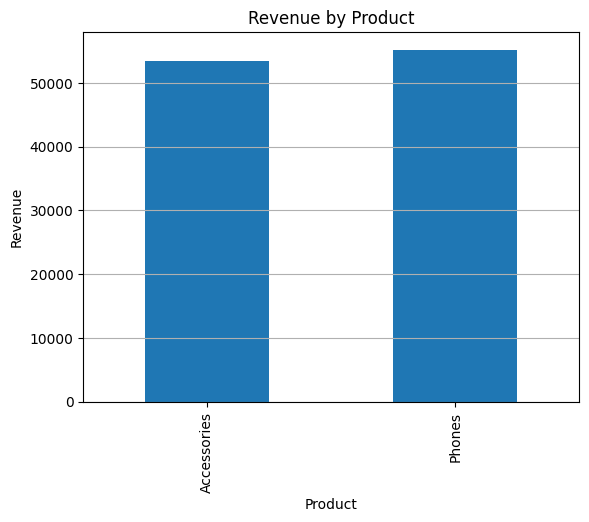

In [38]:
product_revenue = df.groupby("Product")["Revenue"].sum()

plt.figure()
product_revenue.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.grid(axis="y")

plt.savefig("/content/drive/MyDrive/revenue_by_product.png")
plt.show()

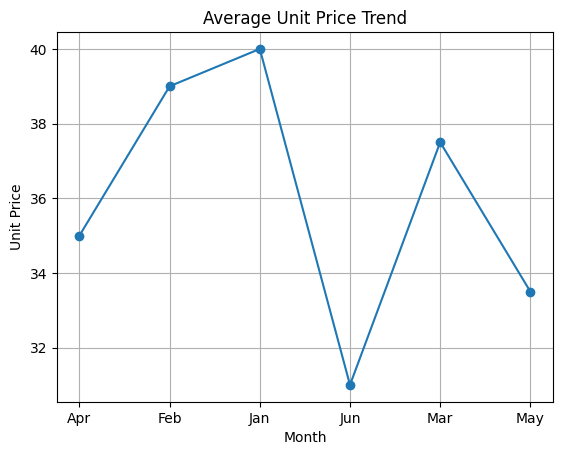

In [39]:
price_trend = df.groupby("Month")["Unit Price"].mean()

plt.figure()
price_trend.plot(marker='o')
plt.title("Average Unit Price Trend")
plt.xlabel("Month")
plt.ylabel("Unit Price")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/unit_price_trend.png")
plt.show()

In [40]:
kpi_path = "/content/drive/MyDrive/sales_kpis.csv"
kpis.to_csv(kpi_path, index=False)

kpi_path

'/content/drive/MyDrive/sales_kpis.csv'

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import os

project_folder = "/content/drive/MyDrive/Phones_Accessories_Data_Analysis"

os.makedirs(project_folder, exist_ok=True)

project_folder

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis'

In [43]:
data_path = f"{project_folder}/sales_data.csv"
df.to_csv(data_path, index=False)

data_path

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/sales_data.csv'

In [44]:
kpi_path = f"{project_folder}/sales_kpis.csv"
kpis.to_csv(kpi_path, index=False)

kpi_path

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/sales_kpis.csv'

In [45]:
charts_folder = f"{project_folder}/charts"
os.makedirs(charts_folder, exist_ok=True)

charts_folder

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/charts'

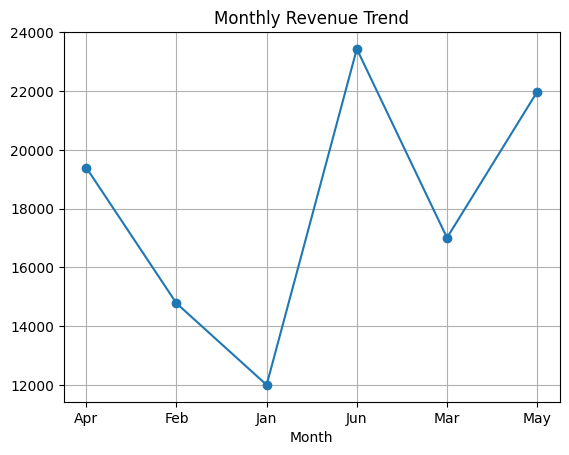

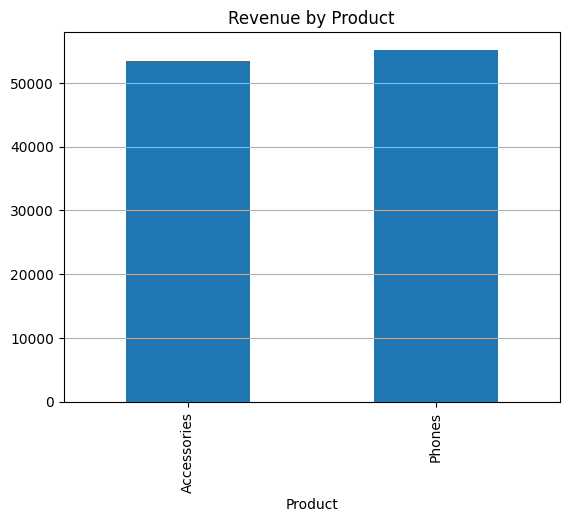

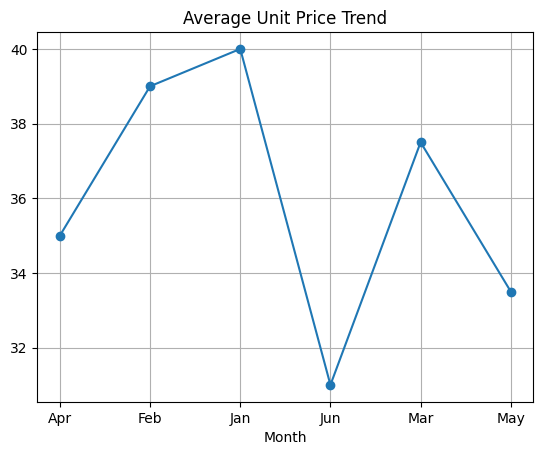

In [46]:
plt.figure()
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.grid(True)
plt.savefig(f"{charts_folder}/monthly_revenue_trend.png")
plt.show()

plt.figure()
product_revenue.plot(kind="bar")
plt.title("Revenue by Product")
plt.grid(axis="y")
plt.savefig(f"{charts_folder}/revenue_by_product.png")
plt.show()

plt.figure()
price_trend.plot(marker='o')
plt.title("Average Unit Price Trend")
plt.grid(True)
plt.savefig(f"{charts_folder}/unit_price_trend.png")
plt.show()

In [47]:
!cp "/content/*.ipynb" "/content/drive/MyDrive/Phones_Accessories_Data_Analysis/"

cp: cannot stat '/content/*.ipynb': No such file or directory


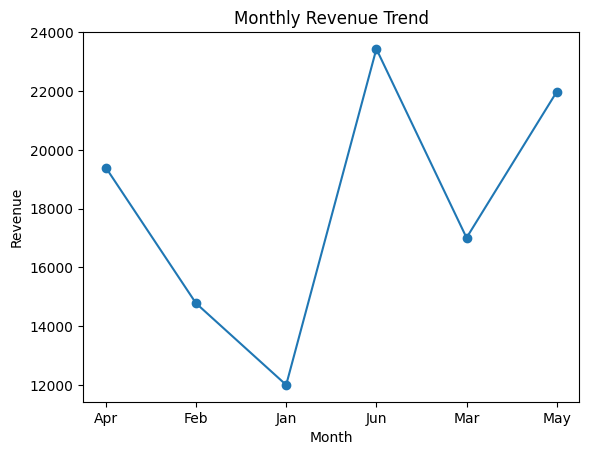

In [48]:
plt.figure()
monthly_revenue.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig(f"{charts_folder}/monthly_revenue_trend_no_grid.png")
plt.show()

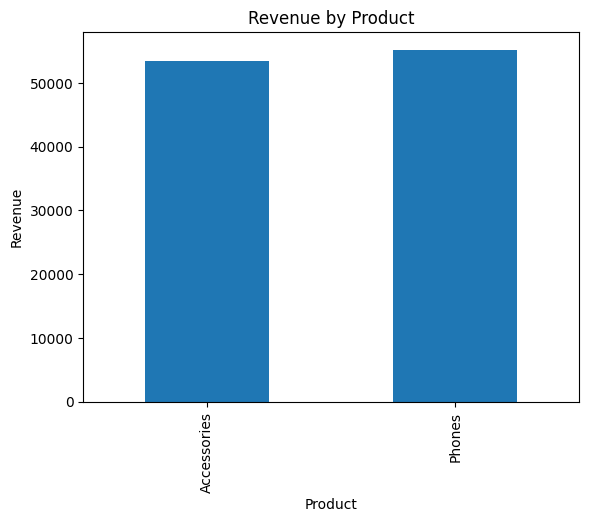

In [49]:
plt.figure()
product_revenue.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.savefig(f"{charts_folder}/revenue_by_product_no_grid.png")
plt.show()

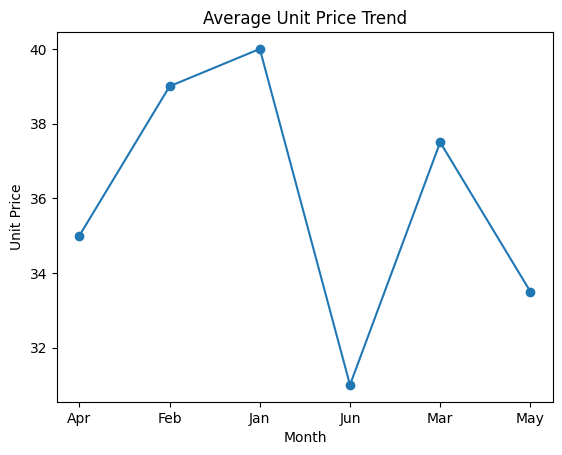

In [50]:
plt.figure()
price_trend.plot(marker='o')
plt.title("Average Unit Price Trend")
plt.xlabel("Month")
plt.ylabel("Unit Price")

plt.savefig(f"{charts_folder}/unit_price_trend_no_grid.png")
plt.show()

/tmp/ipython-input-1374/3751541620.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for dashboard title


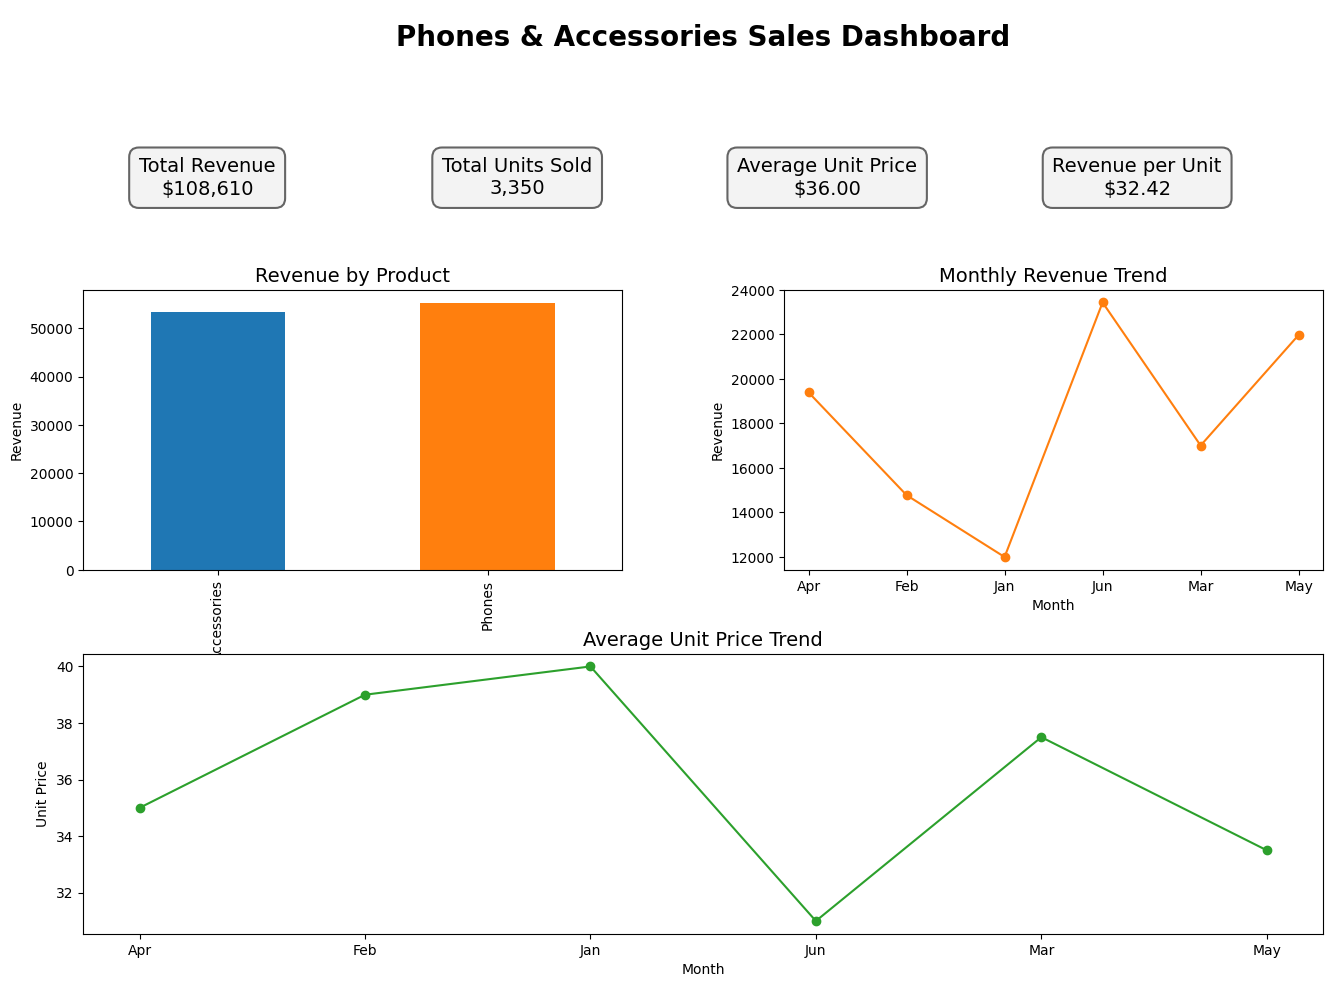

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/charts/executive_dashboard_final.png'

In [51]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create figure
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(4, 2, height_ratios=[0.2, 0.2, 1, 1], width_ratios=[1,1], hspace=0.5, wspace=0.3)

# 0️⃣ Dashboard Title (full width)
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")
ax_title.text(0.5, 0.5, "Phones & Accessories Sales Dashboard", fontsize=20, ha="center", va="center", fontweight='bold')

# 1️⃣ KPIs (display as boxes)
ax_kpi = fig.add_subplot(gs[1, :])
ax_kpi.axis("off")

# KPI boxes: manually place using text and bbox
kpi_style = dict(boxstyle="round,pad=0.5", facecolor="#f2f2f2", edgecolor="#555555", alpha=0.9, linewidth=1.5)
ax_kpi.text(0.1, 0.5, f"Total Revenue\n${total_revenue:,.0f}", fontsize=14, ha="center", va="center", bbox=kpi_style)
ax_kpi.text(0.35, 0.5, f"Total Units Sold\n{total_units:,}", fontsize=14, ha="center", va="center", bbox=kpi_style)
ax_kpi.text(0.6, 0.5, f"Average Unit Price\n${avg_price:.2f}", fontsize=14, ha="center", va="center", bbox=kpi_style)
ax_kpi.text(0.85, 0.5, f"Revenue per Unit\n${revenue_per_unit:.2f}", fontsize=14, ha="center", va="center", bbox=kpi_style)

# 2️⃣ Middle Left: Revenue by Product
ax1 = fig.add_subplot(gs[2, 0])
product_revenue.plot(kind="bar", ax=ax1, color=["#1f77b4", "#ff7f0e"])
ax1.set_title("Revenue by Product", fontsize=14)
ax1.set_xlabel("Product")
ax1.set_ylabel("Revenue")
ax1.grid(False)

# 3️⃣ Middle Right: Monthly Revenue Trend
ax2 = fig.add_subplot(gs[2, 1])
monthly_revenue.plot(marker='o', ax=ax2, color="#ff7f0e")
ax2.set_title("Monthly Revenue Trend", fontsize=14)
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")
ax2.grid(False)

# 4️⃣ Bottom (full width): Unit Price Trend
ax3 = fig.add_subplot(gs[3, :])
price_trend.plot(marker='o', ax=ax3, color="#2ca02c")
ax3.set_title("Average Unit Price Trend", fontsize=14)
ax3.set_xlabel("Month")
ax3.set_ylabel("Unit Price")
ax3.grid(False)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for dashboard title

# Save final dashboard image
final_dashboard_path = f"{charts_folder}/executive_dashboard_final.png"
plt.savefig(final_dashboard_path, dpi=300)
plt.show()

final_dashboard_path

In [52]:
from google.colab import drive
import shutil
import os
import pandas as pd

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Recreate project folder
project_folder = "/content/drive/MyDrive/Phones_Accessories_Data_Analysis"
charts_folder = f"{project_folder}/charts"
os.makedirs(charts_folder, exist_ok=True)

# 3️⃣ Recreate dataset
data = {
    "Month": ["Jan","Jan","Feb","Feb","Mar","Mar","Apr","Apr","May","May","Jun","Jun"],
    "Product": ["Phones","Accessories"] * 6,
    "Units Sold": [120,200,150,260,180,310,220,380,260,450,300,520],
    "Unit Price": [50,30,50,28,48,27,45,25,43,24,40,22]
}
df = pd.DataFrame(data)
df["Revenue"] = df["Units Sold"] * df["Unit Price"]

# 4️⃣ Save dataset and KPIs
df.to_csv(f"{project_folder}/sales_data.csv", index=False)

total_revenue = df["Revenue"].sum()
total_units = df["Units Sold"].sum()
avg_price = df["Unit Price"].mean()
revenue_per_unit = total_revenue / total_units

kpis = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Units Sold", "Average Unit Price", "Revenue per Unit"],
    "Value": [total_revenue, total_units, avg_price, revenue_per_unit]
})
kpis.to_csv(f"{project_folder}/sales_kpis.csv", index=False)

# 5️⃣ Create dummy charts (empty plots) to simulate saved images
# Replace with your real chart code if needed
charts = ["monthly_revenue_trend.png","revenue_by_product.png","unit_price_trend.png","executive_dashboard_final.png"]
for chart in charts:
    plt.figure()
    plt.text(0.5,0.5,chart,fontsize=12,ha='center')
    plt.axis('off')
    plt.savefig(f"{charts_folder}/{chart}")
    plt.close()

# 6️⃣ Zip the entire project folder
zip_path = "/content/drive/MyDrive/Phones_Accessories_Data_Analysis.zip"
shutil.make_archive(zip_path.replace(".zip",""), 'zip', project_folder)

zip_path

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/Phones_Accessories_Data_Analysis.zip'

In [54]:
# Path where you want to save it
notebook_path = '/content/drive/MyDrive/Phones_Accessories_Data_Analysis/analysis.ipynb'

# Save current notebook
!cp "/content/Phones_Accessories_Sales_Analysis.ipynb" "{notebook_path}"

notebook_path

cp: cannot stat '/content/Phones_Accessories_Sales_Analysis.ipynb': No such file or directory


'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/analysis.ipynb'

In [55]:
import os
os.listdir('/content/drive/MyDrive/Phones_Accessories_Data_Analysis/')

['charts', 'sales_data.csv', 'sales_kpis.csv', 'README.md', 'requirements.txt']

In [53]:
readme_content = """
# 📊 Phones & Accessories Sales Analysis

## 📌 Project Overview
This project analyzes 6 months of sales data for Phones and Accessories to understand why revenue growth lagged behind increasing sales volume.

## 🎯 Business Problem
Despite rising units sold, revenue growth remained weak due to continuous price reductions.

## 🧾 Dataset
- Month
- Product
- Units Sold
- Unit Price
- Revenue (calculated)

## 🛠 Tools
- Python (Pandas, Matplotlib)
- Google Colab
- Static Dashboard Design

## 📈 Key Insights
- Sales volume increased steadily
- Unit prices declined month-over-month
- Revenue growth relied on quantity, not value
- Phones generated higher revenue efficiency than Accessories

## 💡 Recommendations
- Reduce discount dependency on Accessories
- Focus marketing on higher-value Phones
- Track Revenue per Unit as a core KPI
"""

readme_path = f"{project_folder}/README.md"

with open(readme_path, "w") as f:
    f.write(readme_content)

readme_path

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/README.md'

In [ ]:
import os
os.listdir(project_folder)

['charts', 'sales_data.csv', 'sales_kpis.csv', 'README.md']

In [ ]:
requirements_path = f"{project_folder}/requirements.txt"

with open(requirements_path, "w") as f:
    f.write("pandas\nmatplotlib")

requirements_path

'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/requirements.txt'

In [ ]:
!pip install nbconvert
!jupyter nbconvert --to pdf Phones_Accessories_Sales_Analysis.ipynb

[NbConvertApp] WARNING | pattern 'Phones_Accessories_Sales_Analysis.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_y

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Path where you want to save it
notebook_path = '/content/drive/MyDrive/Phones_Accessories_Data_Analysis/analysis.ipynb'

# Save current notebook
!cp "/content/Phones_Accessories_Sales_Analysis.ipynb" "{notebook_path}"

notebook_path

cp: cannot stat '/content/Phones_Accessories_Sales_Analysis.ipynb': No such file or directory


'/content/drive/MyDrive/Phones_Accessories_Data_Analysis/analysis.ipynb'